# **DOCUMENT VEREFICATION FOR KYC-COMPLIANCE**

In [ ]:
# importing modules
from pathlib import Path
import sys
import numpy as np
from statistics import mode
from PIL import Image
import cv2
from pyexpat import features
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from skimage.feature import hog
from sklearn.decomposition import PCA
import joblib
from sklearn.metrics import roc_curve, auc

print("Python executable:", sys.executable)

# Resolve YOLO weights explicitly to avoid CWD-related failures.
MODEL_CANDIDATES = [
    Path(r"D:\Python\Infosys\main\backend\app\models\yolov8n.pt"),
    Path(r"D:\Python\Infosys\main\models\document detection\yolov8n.pt"),
    Path("yolov8n.pt"),
]
model_path = next((p for p in MODEL_CANDIDATES if p.exists()), None)
if model_path is None:
    raise FileNotFoundError(
        "yolov8n.pt not found. Checked: " + ", ".join(str(p) for p in MODEL_CANDIDATES)
    )

print("YOLO weights:", model_path)
yolo = YOLO(str(model_path))

location_aadhar = r"D:\Python\Infosys\datasets\Aadhar images standard"
location_non_aadhar = r"D:\Python\Infosys\datasets\non-aadhar"

# Keep output in the project tree instead of relying on parent depth assumptions.
output_base = Path(r"D:\Python\Infosys\main\preprocessed_train\Aadhar_Output")
output_base.mkdir(parents=True, exist_ok=True)

new_path_aadhar = output_base / "aadhar_standard"
new_path_non_aadhar = output_base / "non_aadhar_standard"

# Local dataset paths
path_aadhar = Path(location_aadhar)
path_non_aadhar = Path(location_non_aadhar)

new_path_aadhar.mkdir(parents=True, exist_ok=True)
new_path_non_aadhar.mkdir(parents=True, exist_ok=True)

extension = ".jpg"
non_compliant_file_count = 0
dimensions = []
DPI = []

def process_metadata(path):
    global non_compliant_file_count
    if not path.exists():
        print(f"Warning: Input path {path} does not exist.")
        return
    for file in path.iterdir():
        if file.is_file() and file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                with Image.open(file) as img:
                    print(
                        f" Image: {file.name} | format : {img.format} | DPI : {img.info.get('dpi', None)} | Dimensions : {img.size}"
                    )
                    dimensions.append(img.size)
                    DPI.append(img.info.get("dpi", None))
            except Exception as e:
                print(f"Skipping {file.name}: {e}")
                non_compliant_file_count += 1

print("Processing Aadhar metadata:")
process_metadata(path_aadhar)
print("\nProcessing Non-Aadhar metadata:")
process_metadata(path_non_aadhar)

Python executable: d:\Python\Infosys\main\backend\.venv\Scripts\python.exe
YOLO weights: D:\Python\Infosys\main\backend\app\models\yolov8n.pt
Processing Aadhar metadata:
 Image: 1.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 10.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 100.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 101.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 102.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 103.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 104.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 105.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 106.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 107.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 108.jpg | format : JPEG | DPI : None | Dimensions : (640, 480)
 Image: 109.jpg | format : JPEG | DPI : None | Dimen

In [ ]:
dpi_clean = [d for d in DPI if d is not None]
dims_clean = [d for d in dimensions if d is not None]

print(f"Mode DPI: {Counter(dpi_clean).most_common(1)[0][0] if dpi_clean else None}")
print(f"Mode dimension: {Counter(dims_clean).most_common(1)[0][0] if dims_clean else None}")

Mode DPI: (150, 150)
Mode dimension: (640, 480)


## **Standardizing the dimensions of images to 640x480**

In [ ]:
def resize_images(input_path, output_path):
    if not input_path.exists():
        print(f"Path {input_path} does not exist, skipping resizing.")
        return
    output_path.mkdir(parents=True, exist_ok=True)
    for file in input_path.iterdir():
        if file.is_file() and file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                with Image.open(file) as img:
                    img_resized = img.resize((640, 480))
                    img_resized.save(output_path / file.name)
            except Exception as e:
                print(f"Could not resize {file.name}: {e}")

print("Resizing Aadhar images:")
resize_images(path_aadhar, new_path_aadhar)
print("\nResizing Non-Aadhar images:")
resize_images(path_non_aadhar, new_path_non_aadhar)
# %%
# Further processing or classification can be added here

Resizing Aadhar images:

Resizing Non-Aadhar images:
Could not resize 293.jpg: cannot write mode RGBA as JPEG
Could not resize 294.jpg: cannot write mode RGBA as JPEG


#TODO Gray Scaling Images

In [ ]:
def normalization_of_image(input_path, output_subdir):
    file_path = Path(input_path)
    if not file_path.exists():
        print(f"Invalid path: {input_path}")
        return

    save_dir = output_base / output_subdir
    save_dir.mkdir(parents=True, exist_ok=True)

    for file in file_path.iterdir():
        if file.is_file() and file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                # Load image
                img = cv2.imread(str(file))
                if img is None:
                    print(f"Skipping {file.name}: Could not read image")
                    continue

                # Convert to grayscale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Save the file
                save_path = save_dir / file.name
                cv2.imwrite(str(save_path), gray)

            except Exception as e:
                print(f"Error converting {file.name} to grayscale: {e}")

print("Converting Aadhar images to grayscale:")
normalization_of_image(new_path_aadhar, "grayscale_aadhar")
print("\nConverting Non-Aadhar images to grayscale:")
normalization_of_image(new_path_non_aadhar, "grayscale_non_aadhar")


Converting Aadhar images to grayscale:

Converting Non-Aadhar images to grayscale:


In [ ]:
def image_standardization(location, label, use_hog=True):
    all_images, img_tag = [], []
    path = Path(location)
    if not path.exists():
        print(f"Invalid path: {location}")
        return [], []
    for file in path.iterdir():
        if file.is_file() and file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    print(f"Unable to read {file.name}: Not a valid image")
                    continue

                # Resize to a fixed size for HOG consistency if needed
                img_resized = cv2.resize(img, (128, 128))

                if use_hog:
                    # Extract HOG features
                    features = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=False)
                    all_images.append(features)
                else:
                    flattened = img_resized.flatten() / 255.0
                    all_images.append(flattened)

                img_tag.append(label)
            except Exception as e:
                print(f"Unable to read {file.name}: {e}")
    return all_images, img_tag

# Load data with HOG features
X_aadhar, Y_aadhar = image_standardization(output_base / "grayscale_aadhar", 1, use_hog=True)
X_non_aadhar, Y_non_aadhar = image_standardization(output_base / "grayscale_non_aadhar", 0, use_hog=True)

X = np.array(X_aadhar + X_non_aadhar)
Y = np.array(Y_aadhar + Y_non_aadhar)


## **GRAPH ANALYSIS**


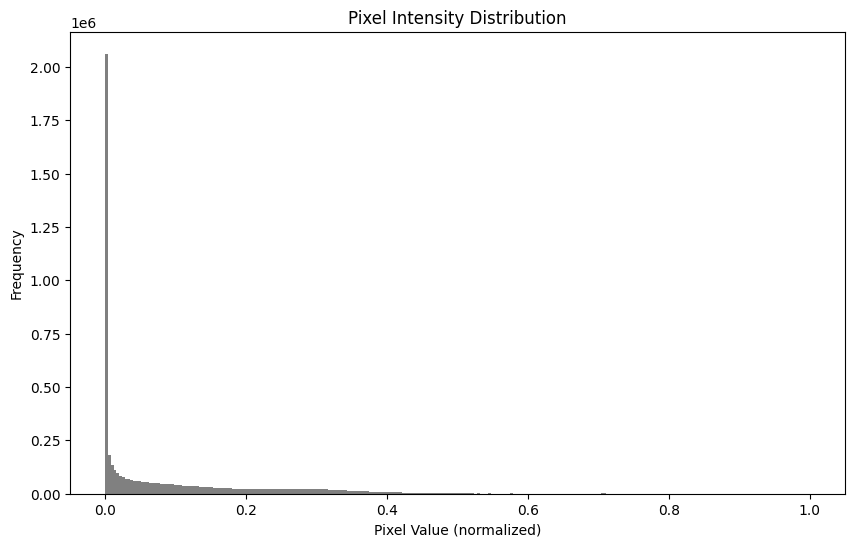

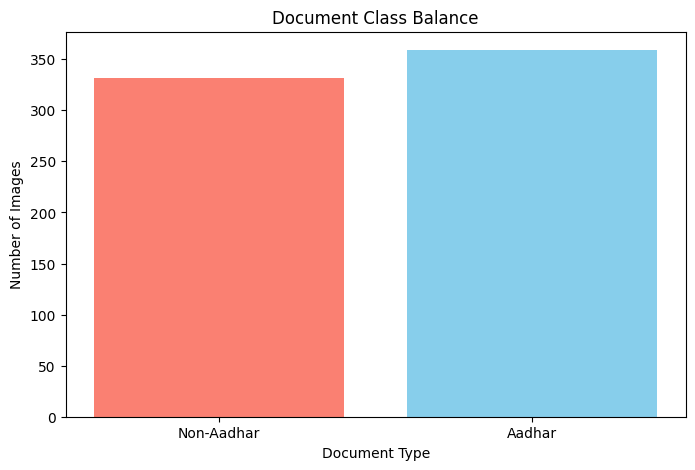

In [ ]:
# Plotting Pixel Intensity Distribution
plt.figure(figsize=(10, 6))
plt.hist(X.ravel(), bins=256, color='gray')
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value (normalized)')
plt.ylabel('Frequency')
plt.savefig(r'D:\Python\pixel_distribution.png')
plt.show()

# Plotting Class Balance
labels, counts = np.unique(Y, return_counts=True)
label_names = ['Non-Aadhar', 'Aadhar']
plt.figure(figsize=(8, 5))
plt.bar(label_names, counts, color=['salmon', 'skyblue'])
plt.title('Document Class Balance')
plt.xlabel('Document Type')
plt.ylabel('Number of Images')
plt.show()


#### **THE NUMBER OF AADHAR IMAGES PROVIDED IS EQUIVILENT TO NON AADHAR IMAGES PROVIDED**

### **SPLITTING THE DATASET**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=56, stratify=Y)
print(f"Training class distribution: {Counter(y_train)}")
print(f"Testing class distribution: {Counter(y_test)}")


scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)



Training class distribution: Counter({1: 287, 0: 265})
Testing class distribution: Counter({1: 72, 0: 67})


#### **Based on the accuracy score of 80% percent we'll use Principal analyis for more accuracy**

In [ ]:
pca = PCA(n_components=0.76)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)
print(x_train_pca.shape)
print(x_train_scaled.shape)

(552, 188)
(552, 8100)


## **MODEL FITTING AND TESTING**

In [ ]:
#model_selection
ls = LogisticRegression()
model = ls.fit(x_train_pca,y_train)
pred_ls = model.predict(x_test_pca)
score = accuracy_score(y_test, pred_ls)
print(f"Accuracy: {score}")

Accuracy: 0.8057553956834532


#### **Hyperparameter Tuning for SVM**

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}
grid_svm = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=1, cv=5)
grid_svm.fit(x_train_pca, y_train)

print(f"Best Parameters: {grid_svm.best_params_}")
ypred_svm = grid_svm.predict(x_test_pca)
print(f"SVM Accuracy After Tuning: {accuracy_score(y_test, ypred_svm)}")
print(classification_report(y_test, ypred_svm))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'poly'}
SVM Accuracy After Tuning: 0.8776978417266187
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        67
           1       0.94      0.82      0.87        72

    accuracy                           0.88       139
   macro avg       0.88      0.88      0.88       139
weighted avg       0.88      0.88      0.88       139



In [ ]:
#model evaluation using confusion matrix
ls_cnf_matrix = confusion_matrix(y_test, pred_ls)
svm_cnf_matrix = confusion_matrix(y_test, ypred_svm)
print(ls_cnf_matrix,"\n")
print(svm_cnf_matrix)

[[54 13]
 [14 58]] 

[[63  4]
 [13 59]]


## **CONFUSION MATRIX AND ROC CURVE**

<Axes: >

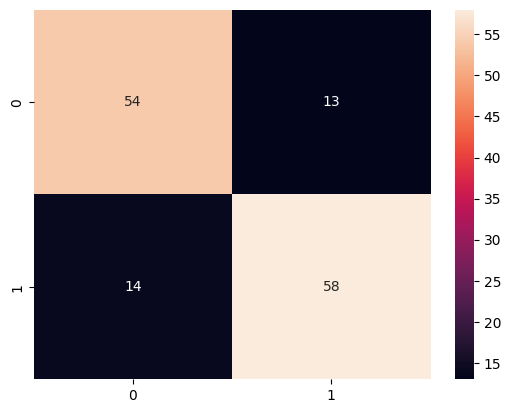

In [ ]:
sns.heatmap(ls_cnf_matrix,annot=True,fmt ='g',cmap="rocket")

<Axes: >

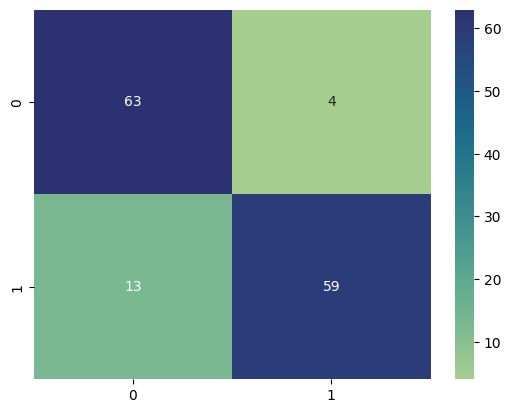

In [ ]:
sns.heatmap(svm_cnf_matrix,annot=True, fmt='g', cmap = 'crest')

<function matplotlib.pyplot.show(close=None, block=None)>

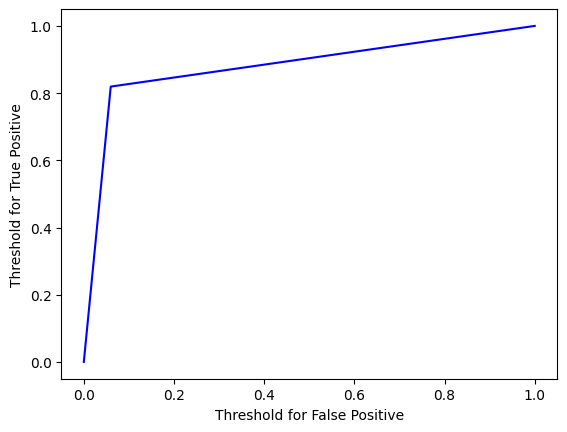

In [ ]:
fpr,tpr,thresholds = roc_curve(y_test,ypred_svm)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label="ROC curve")
plt.xlabel('Threshold for False Positive')
plt.ylabel("Threshold for True Positive")
plt.show

In [ ]:
from sklearn.ensemble import VotingClassifier

# Random Forest with tuning
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=56), rf_params, cv=5, verbose=1, scoring='accuracy')
grid_rf.fit(x_train_pca, y_train)
ypred_rf = grid_rf.predict(x_test_pca)
print(f"Random Forest Best Params: {grid_rf.best_params_}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, ypred_rf):.4f}")

# Ensemble: soft voting (uses predict_proba for weighted average)
ensemble = VotingClassifier(
    estimators=[
        ('svm', grid_svm.best_estimator_),
        ('rf', grid_rf.best_estimator_),
        ('lr', LogisticRegression(max_iter=1000)),
    ],
    voting='soft'
)
ensemble.fit(x_train_pca, y_train)
ypred_ensemble = ensemble.predict(x_test_pca)
print(f"\nEnsemble (SVM+RF+LR) Accuracy: {accuracy_score(y_test, ypred_ensemble):.4f}")
print(classification_report(y_test, ypred_ensemble))

# Compare all models
print("\n--- Model Comparison ---")
print(f"Logistic Regression: {accuracy_score(y_test, pred_ls):.4f}")
print(f"SVM (tuned):         {accuracy_score(y_test, ypred_svm):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, ypred_rf):.4f}")
print(f"Ensemble:            {accuracy_score(y_test, ypred_ensemble):.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 500}
Random Forest Accuracy: 0.8273

Ensemble (SVM+RF+LR) Accuracy: 0.8201
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        67
           1       0.83      0.82      0.83        72

    accuracy                           0.82       139
   macro avg       0.82      0.82      0.82       139
weighted avg       0.82      0.82      0.82       139


--- Model Comparison ---
Logistic Regression: 0.8058
SVM (tuned):         0.8777
Random Forest:       0.8273
Ensemble:            0.8201


#### **After various optimization method we were able to boost the score from 79% to 83%**

#### **IMPLEMENTING YOLO FO DOCUMENT DETECTION**

In [ ]:
clahe_clf = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def classify_document(cropped_img) -> tuple:
    is_aadhar = False
    gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (256, 256))

    # Match training preprocessing: CLAHE + same HOG params
    resized = clahe_clf.apply(resized)

    features = hog(resized, orientations=12, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    features = features.reshape(1, -1)

    features_scaled = scaler.transform(features)
    features_pca = pca.transform(features_scaled)

    # Use ensemble for better prediction
    prob = ensemble.predict_proba(features_pca)
    confidence = prob[0][1]  # Probability of class 1 (Aadhar)
    if confidence > 0.6:
        is_aadhar = True

    label = "Aadhar" if is_aadhar else "Non-Aadhar"
    return label, confidence

In [ ]:
def order_points(pts: np.ndarray) -> np.ndarray:
    pts = np.array(pts, dtype='float32')
    s = pts.sum(axis=1)
    diff = np.diff(pts,axis=1).reshape(-1)

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    return np.array([tl, tr, br, bl], dtype="float32")

def four_point_warp(image_bgr: np.ndarray, pts: np.ndarray) -> np.ndarray:
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = int(max(widthA, widthB))

    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = int(max(heightA, heightB))

    dst = np.array(
        [[0, 0], [maxWidth - 1, 0], [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]],
        dtype="float32",
    )

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image_bgr, M, (maxWidth, maxHeight))
    return warped

def detect_paper_quad(
    image_bgr: np.ndarray,
    min_area_ratio: float = 0.12,
    canny1: int = 50,
    canny2: int = 150,
) -> tuple[np.ndarray | None, dict]:
    """
    Returns (quad_points or None, debug_dict).
    quad_points: shape (4,2) float32 in ORIGINAL image coordinates.
    """
    debug = {}
    h, w = image_bgr.shape[:2]
    frame_area = float(h * w)
    min_area = min_area_ratio * frame_area

    # --- Strategy 1: Downscale + heavy blur to suppress internal text/patterns ---
    scale = 0.5
    small = cv2.resize(image_bgr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    # Strong bilateral filter preserves edges while blurring texture
    gray_blur = cv2.bilateralFilter(gray, 11, 75, 75)
    gray_blur = cv2.GaussianBlur(gray_blur, (7, 7), 0)

    edges = cv2.Canny(gray_blur, canny1, canny2)
    # Heavier morphology to close gaps and merge broken edges
    kernel_close = np.ones((9, 9), np.uint8)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=2)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close, iterations=2)

    debug["edges"] = cv2.resize(edges, (w, h), interpolation=cv2.INTER_NEAREST)
    debug["gray"] = cv2.resize(gray, (w, h))

    # Try to find quad from contours
    quad = _find_quad_from_edges(edges, min_area * scale * scale, scale, debug)
    if quad is not None:
        debug["strategy"] = "downscale+bilateral"
        return quad, debug

    # --- Strategy 2: Adaptive threshold (works when Canny fails on low-contrast docs) ---
    gray2 = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.GaussianBlur(gray2, (11, 11), 0)
    thresh = cv2.adaptiveThreshold(gray2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, 21, 5)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    debug["edges_adaptive"] = cv2.resize(thresh, (w, h), interpolation=cv2.INTER_NEAREST)

    quad = _find_quad_from_edges(thresh, min_area * scale * scale, scale, debug)
    if quad is not None:
        debug["strategy"] = "adaptive_threshold"
        return quad, debug

    # --- Strategy 3: Fallback — use convex hull + min area rect of largest contour ---
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for c in contours[:5]:
        area = cv2.contourArea(c)
        if area < min_area * scale * scale:
            continue
        hull = cv2.convexHull(c)
        rect = cv2.minAreaRect(hull)
        box = cv2.boxPoints(rect)
        quad = (box / scale).astype(np.float32)
        bw, bh = rect[1]
        aspect = max(bw, bh) / (min(bw, bh) + 1e-6)
        if aspect > 5.0:
            continue
        debug["chosen_contour_area"] = float(area / (scale * scale))
        debug["chosen_aspect"] = float(aspect)
        debug["strategy"] = "convex_hull_minAreaRect"
        return quad, debug

    return None, debug


def _find_quad_from_edges(edges, min_area, scale, debug):
    """Helper: find a 4-point quad from an edge image."""
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for c in contours[:20]:
        area = cv2.contourArea(c)
        if area < min_area:
            continue

        peri = cv2.arcLength(c, True)

        # Try progressively larger epsilon
        approx = None
        for eps in [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]:
            candidate = cv2.approxPolyDP(c, eps * peri, True)
            if len(candidate) == 4:
                approx = candidate
                debug["used_epsilon"] = eps
                break

        if approx is None:
            continue

        # Scale back to original image coordinates
        quad = (approx.reshape(4, 2) / scale).astype(np.float32)

        # Aspect ratio filter
        rect = cv2.boundingRect(approx)
        _, _, bw, bh = rect
        aspect = bw / float(bh + 1e-6)
        if aspect < 0.15 or aspect > 6.0:
            continue

        debug["chosen_contour_area"] = float(area / (scale * scale))
        debug["chosen_aspect"] = float(aspect)
        return quad

    return None

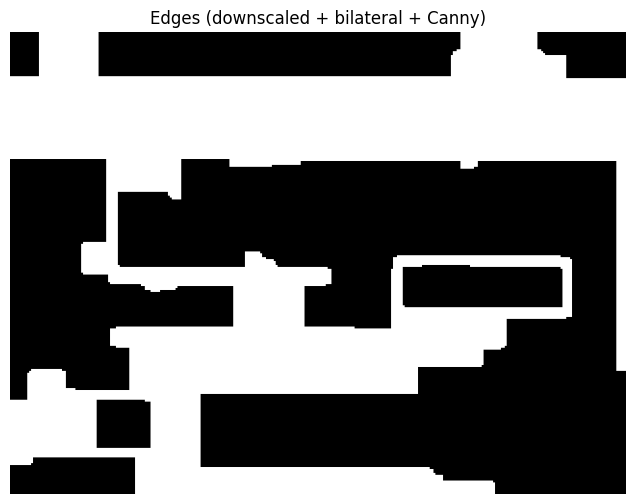

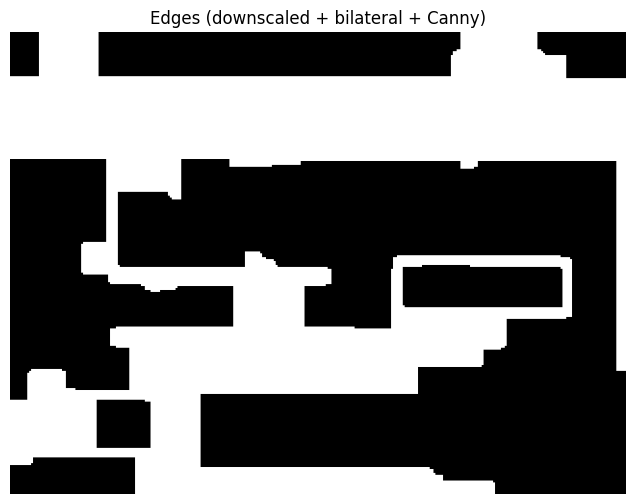

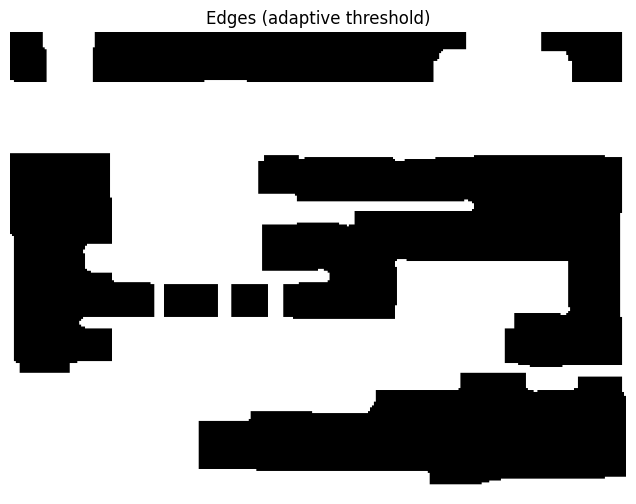

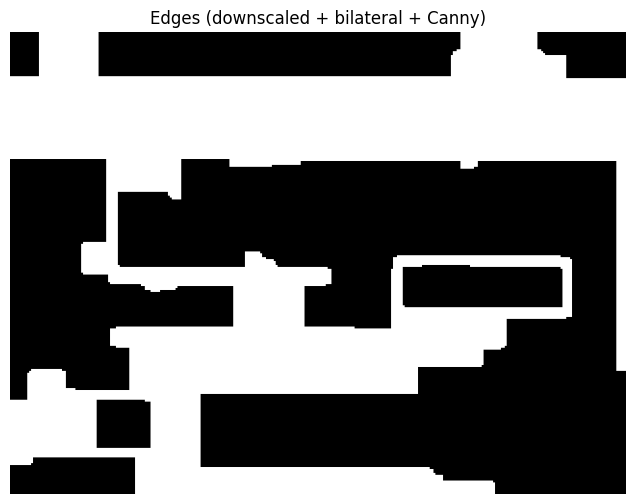

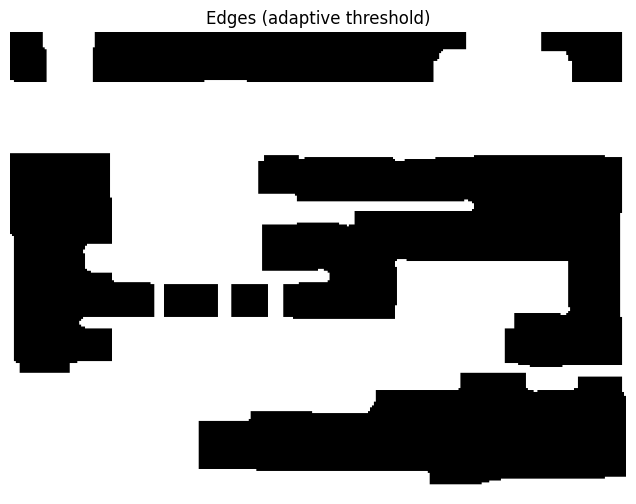

Detected quad points: [[        638         478]
 [-1.4635e-14         478]
 [          0           0]
 [        638           0]]
Strategy: convex_hull_minAreaRect
Area: 136458.0, Aspect: 1.3347280278881672
Epsilon: N/A (minAreaRect)


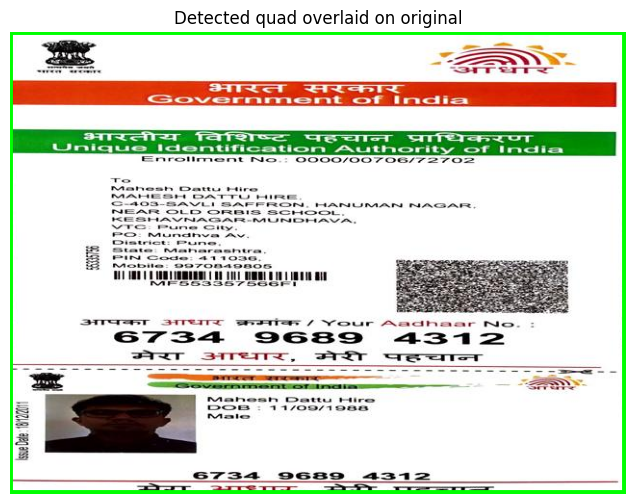

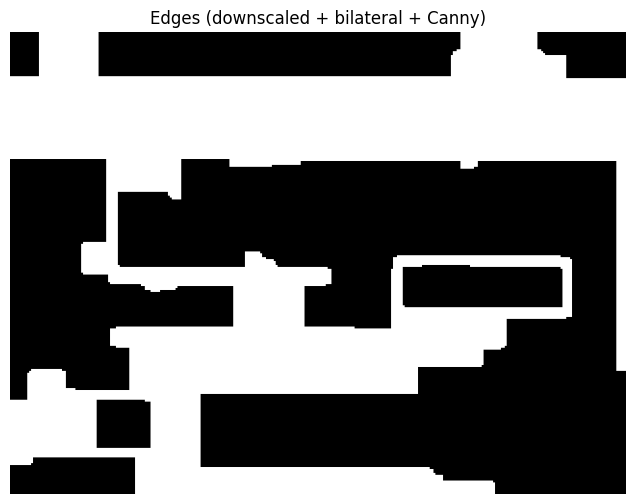

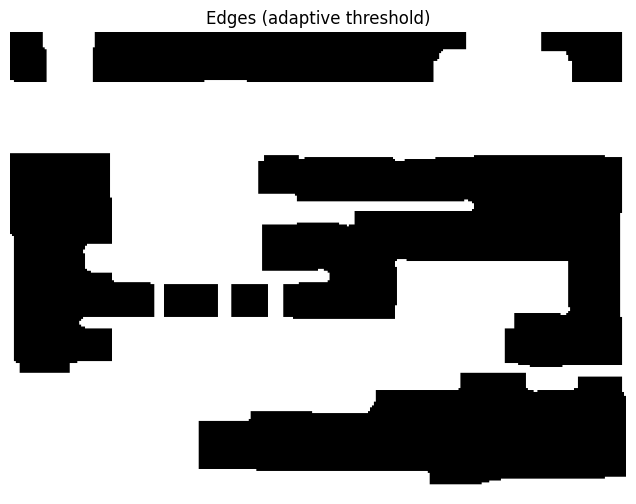

Detected quad points: [[        638         478]
 [-1.4635e-14         478]
 [          0           0]
 [        638           0]]
Strategy: convex_hull_minAreaRect
Area: 136458.0, Aspect: 1.3347280278881672
Epsilon: N/A (minAreaRect)


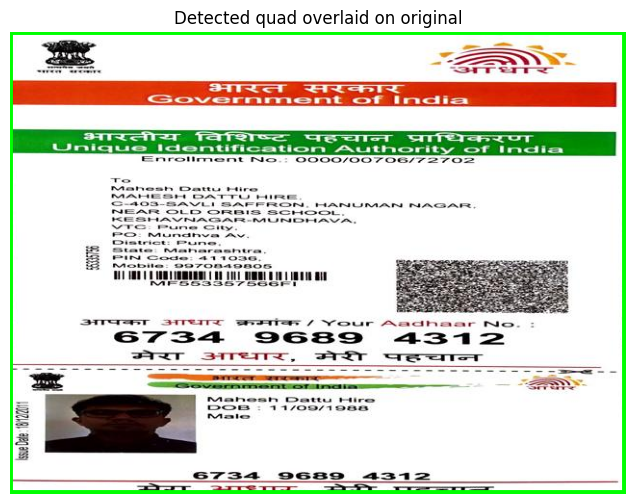

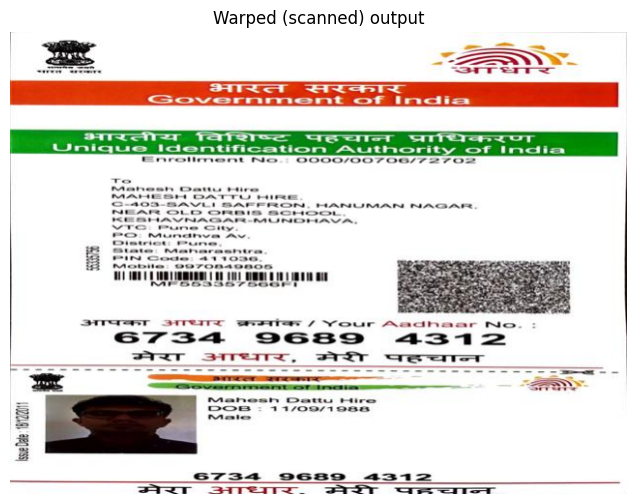

In [ ]:
aadhar_img = r"D:\Python\Infosys\datasets\Aadhar images standard\14.jpg"

def show(img, title="", cmap=None):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

def draw_quad(image_bgr: np.ndarray, quad: np.ndarray) -> np.ndarray:
    out = image_bgr.copy()
    cv2.polylines(out, [quad.astype(int)], True, (0, 255, 0), 3)
    return out

img = cv2.imread(aadhar_img)
if img is None:
    raise ValueError("Could not read image. Check path and file type.")

# --- Run detection ---
quad, dbg = detect_paper_quad(img, min_area_ratio=0.10, canny1=50, canny2=150)

# Show edge maps
show(dbg["edges"], "Edges (downscaled + bilateral + Canny)", cmap="gray")
if "edges_adaptive" in dbg:
    show(dbg["edges_adaptive"], "Edges (adaptive threshold)", cmap="gray")

if quad is None:
    print("No paper quad detected.")
    show(img, "Original image")
else:
    print(f"Detected quad points: {quad}")
    print(f"Strategy: {dbg.get('strategy')}")
    print(f"Area: {dbg.get('chosen_contour_area')}, Aspect: {dbg.get('chosen_aspect')}")
    print(f"Epsilon: {dbg.get('used_epsilon', 'N/A (minAreaRect)')}")
    show(draw_quad(img, quad), "Detected quad overlaid on original")

    warped = four_point_warp(img, quad)
    show(warped, "Warped (scanned) output")

In [ ]:
def main(img_path) -> bool:
    img  = cv2.imread(img_path)
    
    if img is None:
        raise FileNotFoundError(" The file does not exist or cannot be read.")
    quad,dbg = detect_paper_quad(img,min_area_ratio=0.10,canny1=110,canny2=150)
    candidate_img = []
    if quad is None:
        return F" No credential document detected in the image. Please ensure the document is fully visible and try again."
    else:
        candidate_img.append(four_point_warp(quad, dbg))
        print(f"Detected quad points: {quad}")
    
    for img in candidate_img:
        label,confidence = classify_document(img)
        print(F" Detected Document: {label} with confidence of {confidence:.2f}")
        if label == "Aadhar" and confidence > 0.80:
            return True
        else:
            False

In [ ]:
joblib.dump(ensemble, "models/document_classifier_ensemble.pk")   # .pk
joblib.dump(scaler, "models/scaler.joblib")                       # .joblib
joblib.dump(pca,"models/pca.joblib")

joblib.dump(model,"models/text_field_classifier.joblib")
joblib.dump(vectorizer,"models/vectorizer.joblib")

In [ ]:
OUT = Path(r"D:\Python\Infosys\main\backend\app\models")
OUT.mkdir(parents=True, exist_ok=True)
joblib.dump(ensemble, OUT / "document_classifier_ensemble.pk")   # .pk
joblib.dump(scaler, OUT / "scaler.joblib")                     # .joblib      
joblib.dump(pca, OUT / "pca.joblib")